# 1주차. 탐색적 데이터 분석(EDA) 및 시각화
### 주제: DACON 갑상선암 진단 분류 데이터

본 노트북은 갑상선암 진단 분류(train.csv) 데이터를 대상으로 탐색적 데이터 분석(EDA)을 수행한다.

## 0. 라이브러리 불러오기 및 데이터 로드

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['font.family'] = 'Noto Sans CJK JP'
plt.rcParams['axes.unicode_minus'] = False
sns.set_style('whitegrid')
plt.rcParams['font.family'] = 'Noto Sans CJK JP'  # 한글 폰트 (seaborn 스타일 적용 이후 재설정)

train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')

print('train shape:', train.shape)
print('test shape:', test.shape)
train.head()

train shape: (87159, 16)
test shape: (46204, 15)


,ID,Age,Gender,Country,Race,Family_Background,Radiation_History,Iodine_Deficiency,Smoke,Weight_Risk,Diabetes,Nodule_Size,TSH_Result,T4_Result,T3_Result,Cancer
0,TRAIN_00000,80,M,CHN,ASN,Positive,Exposed,Sufficient,Non-Smoker,Not Obese,No,0.650355,2.784735,6.744603,2.575820,1
1,TRAIN_00001,37,M,NGA,ASN,Positive,Unexposed,Sufficient,Smoker,Obese,No,2.950430,0.911624,7.303305,2.505317,1
2,TRAIN_00002,71,M,CHN,MDE,Positive,Unexposed,Sufficient,Non-Smoker,Not Obese,Yes,2.200023,0.717754,11.137459,2.381080,0
3,TRAIN_00003,40,F,IND,HSP,Negative,Unexposed,Sufficient,Non-Smoker,Obese,No,3.370796,6.846380,10.175254,0.753023,0
4,TRAIN_00004,53,F,CHN,CAU,Negative,Unexposed,Sufficient,Non-Smoker,Not Obese,No,4.230048,0.439519,7.194450,0.569356,1


## 1. 데이터 기본 정보

In [2]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 87159 entries, 0 to 87158
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   ID                 87159 non-null  str    
 1   Age                87159 non-null  int64  
 2   Gender             87159 non-null  str    
 3   Country            87159 non-null  str    
 4   Race               87159 non-null  str    
 5   Family_Background  87159 non-null  str    
 6   Radiation_History  87159 non-null  str    
 7   Iodine_Deficiency  87159 non-null  str    
 8   Smoke              87159 non-null  str    
 9   Weight_Risk        87159 non-null  str    
 10  Diabetes           87159 non-null  str    
 11  Nodule_Size        87159 non-null  float64
 12  TSH_Result         87159 non-null  float64
 13  T4_Result          87159 non-null  float64
 14  T3_Result          87159 non-null  float64
 15  Cancer             87159 non-null  int64  
dtypes: float64(4), int64(2), str(10)


In [3]:
# 결측치 확인
print('결측치 개수')
print(train.isnull().sum())
print()
print('중복 행 개수:', train.duplicated().sum())

결측치 개수
ID                   0
Age                  0
Gender               0
Country              0
Race                 0
Family_Background    0
Radiation_History    0
Iodine_Deficiency    0
Smoke                0
Weight_Risk          0
Diabetes             0
Nodule_Size          0
TSH_Result           0
T4_Result            0
T3_Result            0
Cancer               0
dtype: int64

중복 행 개수: 0


In [4]:
# 수치형 변수 기술통계
num_cols = ['Age', 'Nodule_Size', 'TSH_Result', 'T4_Result', 'T3_Result']
train[num_cols].describe()

,Age,Nodule_Size,TSH_Result,T4_Result,T3_Result
count,87159.000000,87159.000000,87159.000000,87159.000000,87159.000000
mean,50.860244,2.508098,5.056871,8.248796,2.005002
std,21.638687,1.441928,2.861229,2.165975,0.867013
min,14.000000,0.000000,0.100000,4.500000,0.500000
25%,32.000000,1.270332,2.582845,6.372031,1.254836
50%,51.000000,2.520941,5.059085,8.236789,2.004101
75%,70.000000,3.760938,7.541586,10.126981,2.758032
max,88.000000,5.000000,10.000000,12.000000,3.500000


In [5]:
# 범주형 변수 목록 및 고유값 개수
cat_cols = ['Gender', 'Country', 'Race', 'Family_Background', 'Radiation_History',
            'Iodine_Deficiency', 'Smoke', 'Weight_Risk', 'Diabetes']

for c in cat_cols:
    print(f'{c:20s} | 고유값 개수: {train[c].nunique():3d} | {sorted(train[c].unique())}')

Gender               | 고유값 개수:   2 | ['F', 'M']
Country              | 고유값 개수:  10 | ['BRA', 'CHN', 'DEU', 'GBR', 'IND', 'JPN', 'KOR', 'NGA', 'RUS', 'USA']


Race                 | 고유값 개수:   5 | ['AFR', 'ASN', 'CAU', 'HSP', 'MDE']
Family_Background    | 고유값 개수:   2 | ['Negative', 'Positive']
Radiation_History    | 고유값 개수:   2 | ['Exposed', 'Unexposed']
Iodine_Deficiency    | 고유값 개수:   2 | ['Deficient', 'Sufficient']
Smoke                | 고유값 개수:   2 | ['Non-Smoker', 'Smoker']
Weight_Risk          | 고유값 개수:   2 | ['Not Obese', 'Obese']
Diabetes             | 고유값 개수:   2 | ['No', 'Yes']


## 2. 각 컬럼의 데이터 분포

### 2-1. 수치형 변수 분포 (Histogram)

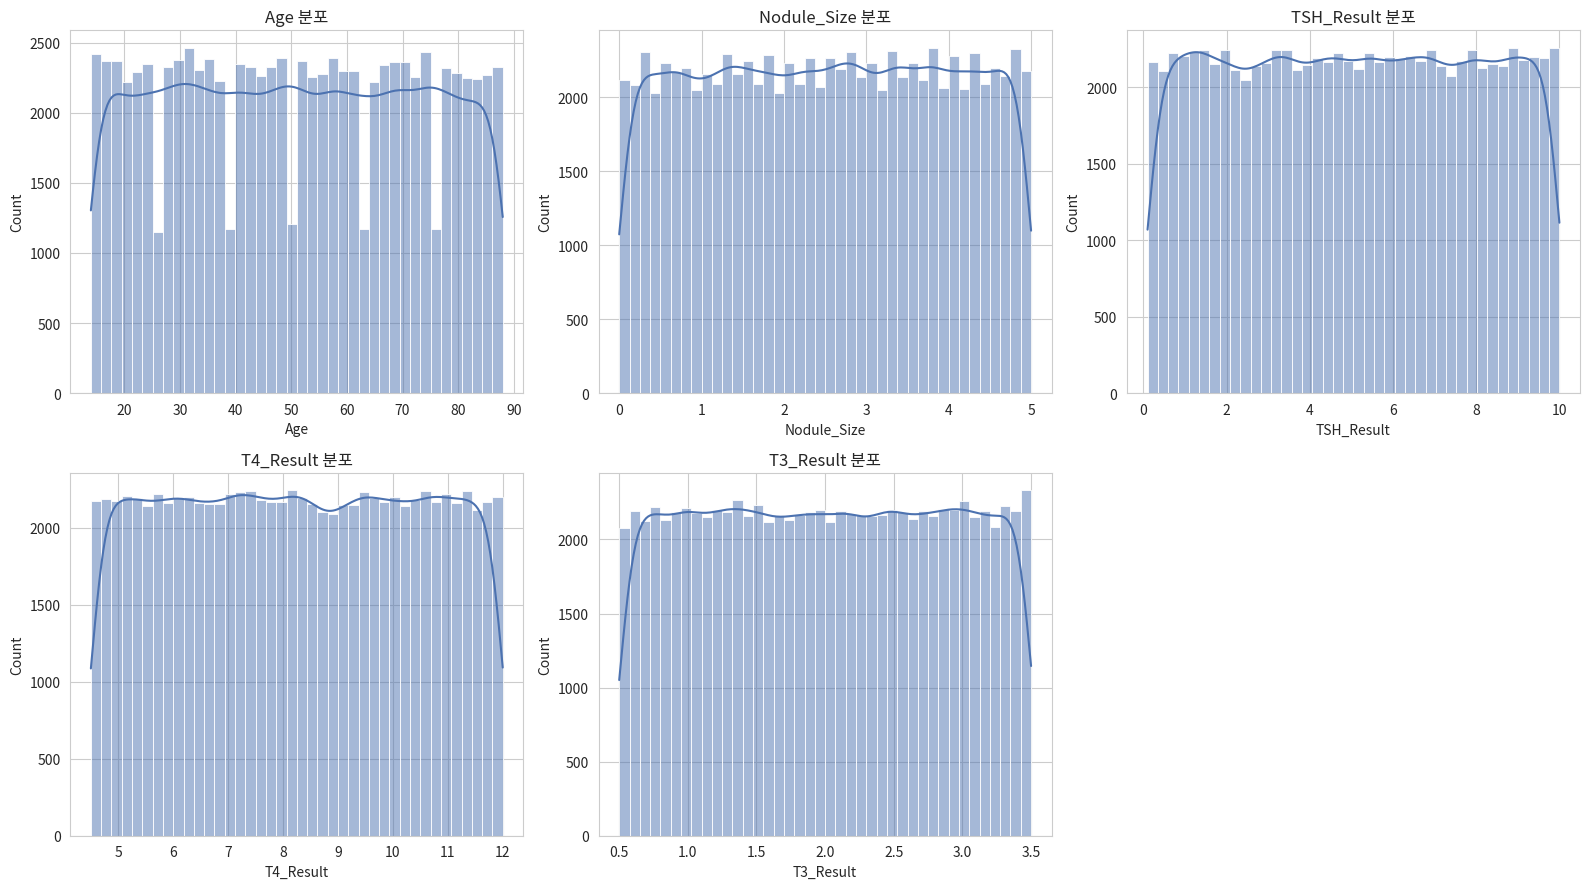

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.histplot(train[col], bins=40, kde=True, ax=axes[i], color='#4C72B0')
    axes[i].set_title(f'{col} 분포')

axes[-1].axis('off')
plt.tight_layout()
plt.savefig('imgs/01_num_hist.png', dpi=120)
plt.show()

### 2-2. 범주형 변수 분포 (Countplot)

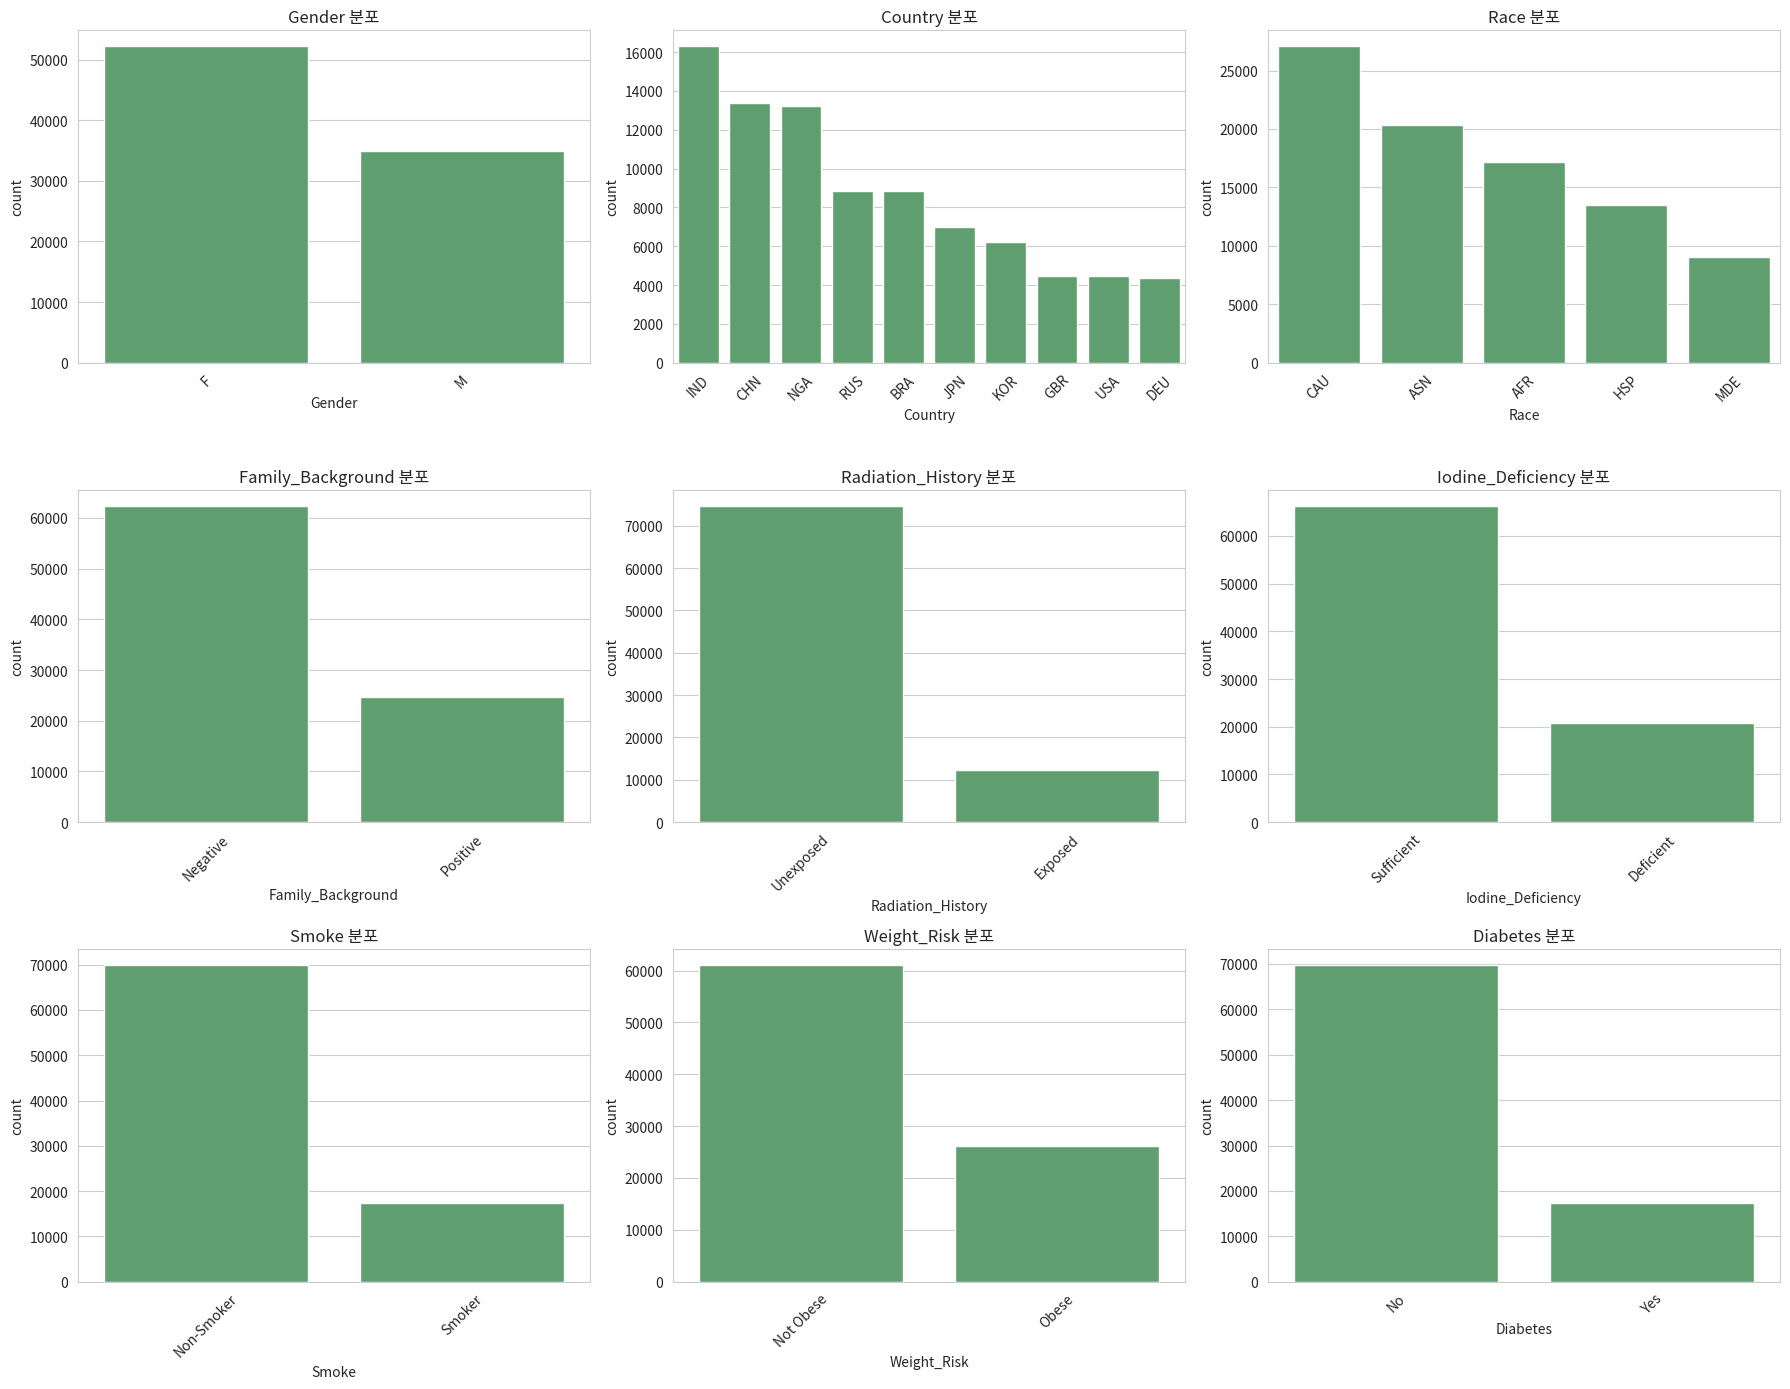

In [7]:
fig, axes = plt.subplots(3, 3, figsize=(18, 14))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    order = train[col].value_counts().index
    sns.countplot(data=train, x=col, order=order, ax=axes[i], color='#55A868')
    axes[i].set_title(f'{col} 분포')
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('imgs/02_cat_count.png', dpi=120)
plt.show()

## 3. 클래스(Target) 분포

Cancer
0    76700
1    10459
Name: count, dtype: int64

Cancer
0    88.0
1    12.0
Name: proportion, dtype: float64


/tmp/ipykernel_571/266317335.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=train, x='Cancer', ax=ax[0], palette=['#4C72B0', '#C44E52'])
/tmp/ipykernel_571/266317335.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[0].set_xticklabels(['0 (양성)', '1 (악성)'])


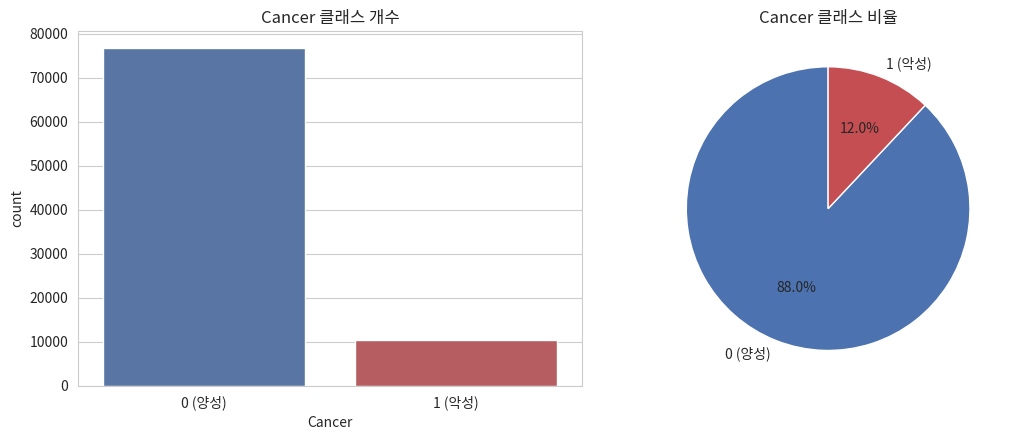

In [8]:
target_counts = train['Cancer'].value_counts()
target_ratio = train['Cancer'].value_counts(normalize=True) * 100

print(target_counts)
print()
print(target_ratio.round(2))

fig, ax = plt.subplots(1, 2, figsize=(11, 4.5))
sns.countplot(data=train, x='Cancer', ax=ax[0], palette=['#4C72B0', '#C44E52'])
ax[0].set_title('Cancer 클래스 개수')
ax[0].set_xticklabels(['0 (양성)', '1 (악성)'])

ax[1].pie(target_counts, labels=['0 (양성)', '1 (악성)'], autopct='%1.1f%%',
          colors=['#4C72B0', '#C44E52'], startangle=90)
ax[1].set_title('Cancer 클래스 비율')

plt.tight_layout()
plt.savefig('imgs/03_target_dist.png', dpi=120)
plt.show()

## 4. 변수 간 상관관계

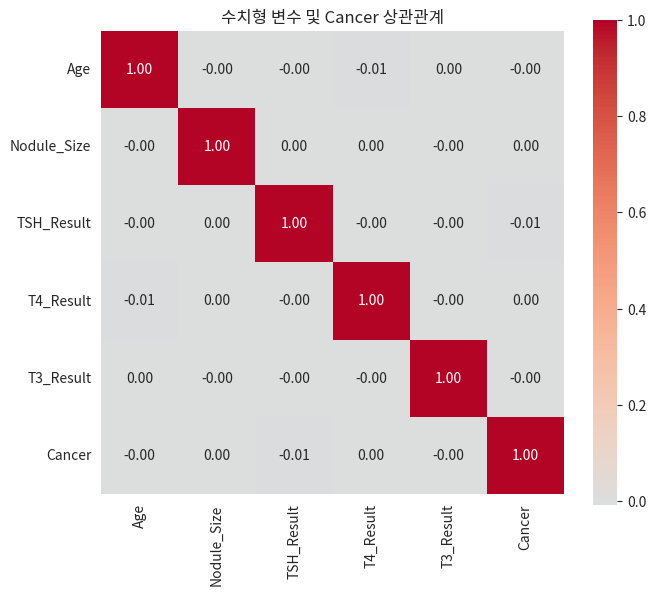

Cancer         1.000000
T4_Result      0.003303
Nodule_Size    0.001074
Age           -0.000872
T3_Result     -0.003533
TSH_Result    -0.008221
Name: Cancer, dtype: float64

In [9]:
corr_cols = num_cols + ['Cancer']
corr = train[corr_cols].corr()

plt.figure(figsize=(7, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True)
plt.title('수치형 변수 및 Cancer 상관관계')
plt.tight_layout()
plt.savefig('imgs/04_corr_heatmap.png', dpi=120)
plt.show()

corr['Cancer'].sort_values(ascending=False)

## 5. 주요 변수별 시각화 (Target 기준 Boxplot)

/tmp/ipykernel_571/3946261076.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=train, x='Cancer', y=col, ax=axes[i], palette=['#4C72B0', '#C44E52'])
/tmp/ipykernel_571/3946261076.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(['0 (양성)', '1 (악성)'])
/tmp/ipykernel_571/3946261076.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=train, x='Cancer', y=col, ax=axes[i], palette=['#4C72B0', '#C44E52'])


/tmp/ipykernel_571/3946261076.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(['0 (양성)', '1 (악성)'])
/tmp/ipykernel_571/3946261076.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=train, x='Cancer', y=col, ax=axes[i], palette=['#4C72B0', '#C44E52'])
/tmp/ipykernel_571/3946261076.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(['0 (양성)', '1 (악성)'])
/tmp/ipykernel_571/3946261076.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=train, x='Cancer', y=col, ax=a

/tmp/ipykernel_571/3946261076.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(['0 (양성)', '1 (악성)'])
/tmp/ipykernel_571/3946261076.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=train, x='Cancer', y=col, ax=axes[i], palette=['#4C72B0', '#C44E52'])
/tmp/ipykernel_571/3946261076.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(['0 (양성)', '1 (악성)'])


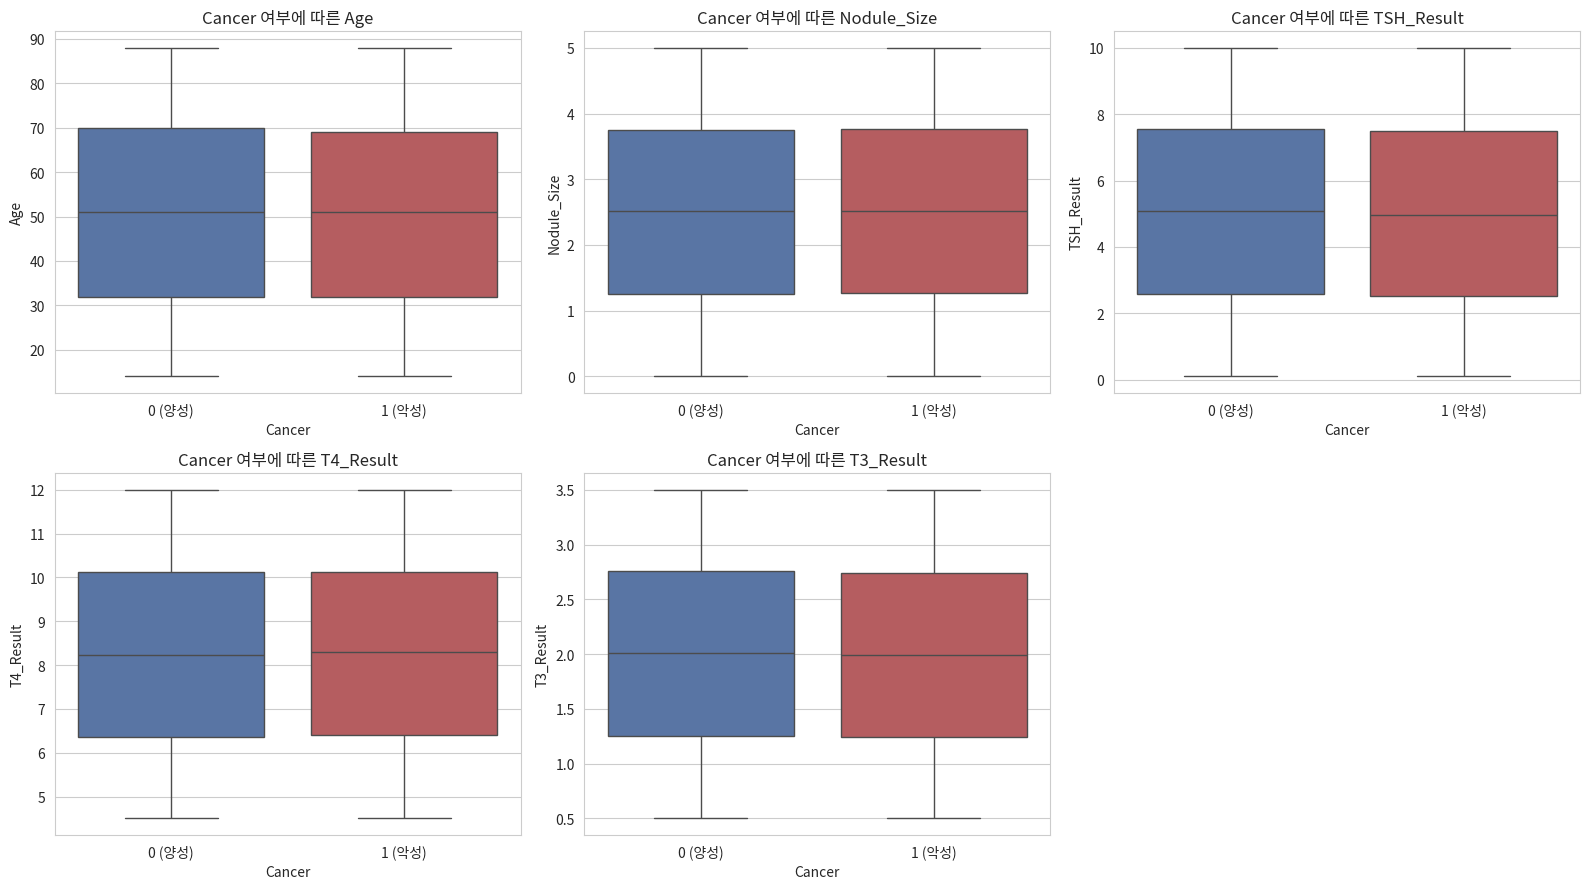

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(data=train, x='Cancer', y=col, ax=axes[i], palette=['#4C72B0', '#C44E52'])
    axes[i].set_title(f'Cancer 여부에 따른 {col}')
    axes[i].set_xticklabels(['0 (양성)', '1 (악성)'])

axes[-1].axis('off')
plt.tight_layout()
plt.savefig('imgs/05_box_by_target.png', dpi=120)
plt.show()

### 5-1. 범주형 변수별 암 발생 비율

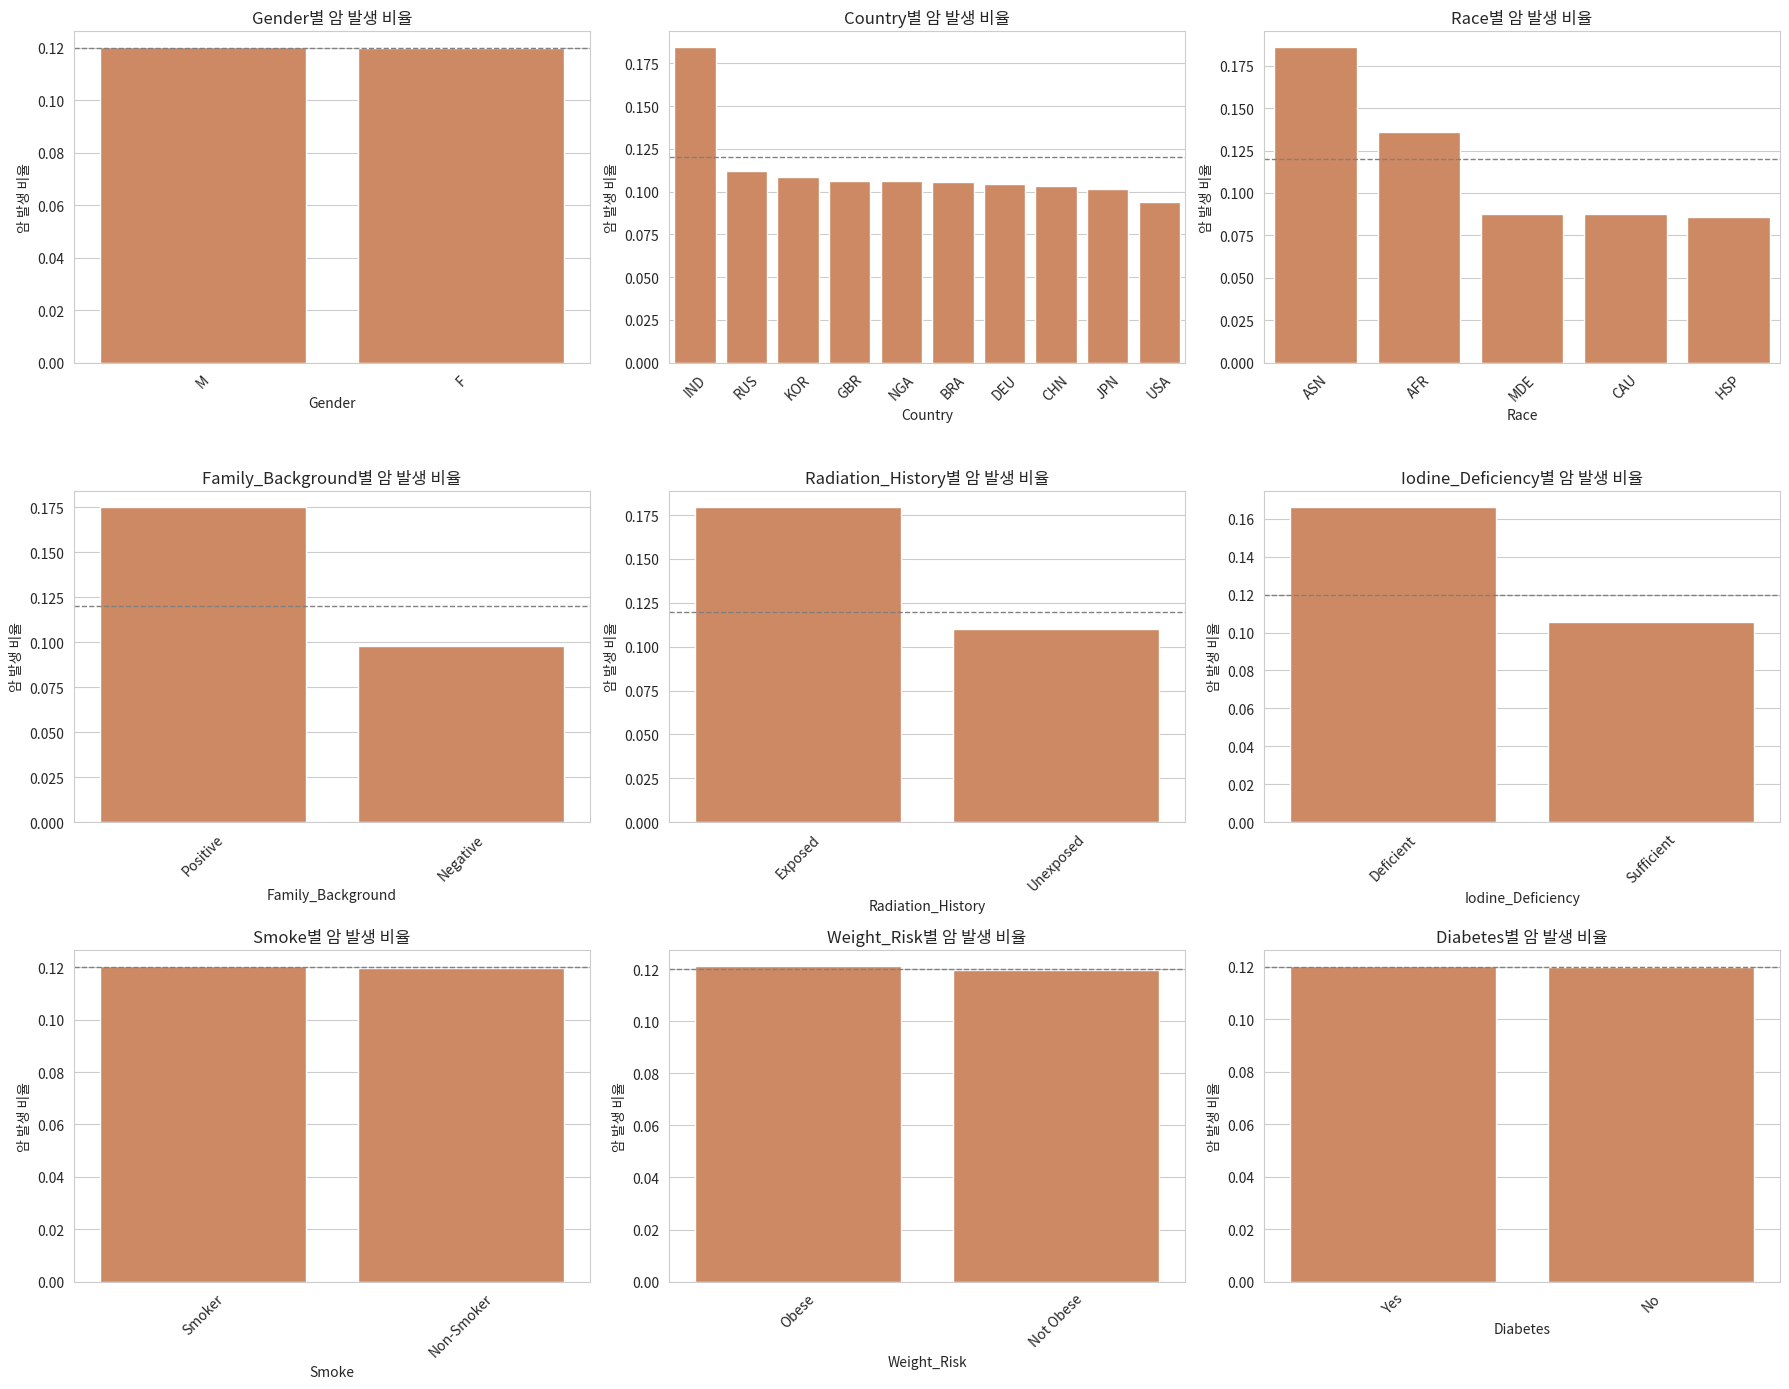

In [11]:
fig, axes = plt.subplots(3, 3, figsize=(18, 14))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    rate = train.groupby(col)['Cancer'].mean().sort_values(ascending=False)
    sns.barplot(x=rate.index, y=rate.values, ax=axes[i], color='#DD8452')
    axes[i].set_title(f'{col}별 암 발생 비율')
    axes[i].set_ylabel('암 발생 비율')
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].axhline(train['Cancer'].mean(), color='gray', linestyle='--', linewidth=1)

plt.tight_layout()
plt.savefig('imgs/06_cat_rate_by_target.png', dpi=120)
plt.show()

## 6. 이상치 확인 (IQR 기준)

In [12]:
def count_outliers_iqr(series):
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return ((series < lower) | (series > upper)).sum()

for col in num_cols:
    n_out = count_outliers_iqr(train[col])
    print(f'{col:15s} | 이상치 개수: {n_out:5d} | 비율: {n_out/len(train)*100:.2f}%')

Age             | 이상치 개수:     0 | 비율: 0.00%
Nodule_Size     | 이상치 개수:     0 | 비율: 0.00%
TSH_Result      | 이상치 개수:     0 | 비율: 0.00%
T4_Result       | 이상치 개수:     0 | 비율: 0.00%
T3_Result       | 이상치 개수:     0 | 비율: 0.00%


## 결론

위 분석 결과에 대한 해석(1-3. 분석 결과, 1-4. 전처리 계획)은 별도 보고서(PDF)에 상세히 기술하였다.